# 02 - Preprocessing

Στόχος αυτού του notebook:
1. Φόρτωση όλων των tables
2. Date parsing και cleaning
3. Joins για τη δημιουργία ενός ενιαίου dataset
4. Handling missing values (κυρίως oil)
5. Holiday handling με conditional logic
6. Αποθήκευση του processed dataset για χρήση στα επόμενα notebooks

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Setup OK")

Setup OK


In [3]:
train = pd.read_csv('../data/raw/train.csv')
stores = pd.read_csv('../data/raw/stores.csv')
oil = pd.read_csv('../data/raw/oil.csv')
holidays = pd.read_csv('../data/raw/holidays_events.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

print(f"train: {train.shape}")
print(f"stores: {stores.shape}")
print(f"oil: {oil.shape}")
print(f"holidays: {holidays.shape}")
print(f"transactions: {transactions.shape}")

train: (3000888, 6)
stores: (54, 5)
oil: (1218, 2)
holidays: (350, 6)
transactions: (83488, 3)


In [4]:
# Μετατροπή σε datetime σε όλους τους πίνακες
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
transactions['date'] = pd.to_datetime(transactions['date'])

# Επιβεβαίωση
print("Datetime conversion done:")
print(f"  train.date: {train['date'].dtype}")
print(f"  oil.date: {oil['date'].dtype}")
print(f"  holidays.date: {holidays['date'].dtype}")
print(f"  transactions.date: {transactions['date'].dtype}")

Datetime conversion done:
  train.date: datetime64[us]
  oil.date: datetime64[us]
  holidays.date: datetime64[us]
  transactions.date: datetime64[us]


## Oil price preprocessing

Το oil dataset έχει:
- 43 missing values (NaN) σε Σαββατοκύριακα/αργίες
- Ολόκληρες ημερομηνίες που λείπουν (π.χ. 2013-01-05/06)

Στρατηγική:
1. Φτιάχνουμε πλήρες χρονικό index από την πρώτη μέχρι την τελευταία ημερομηνία του train
2. Reindex το oil για να καλύψει όλες τις ημερομηνίες
3. Forward fill για να γεμίσουμε τα κενά (standard τεχνική για financial data)
4. Backward fill για την πρώτη γραμμή (αν είναι NaN)

In [5]:
# Φτιάχνουμε πλήρες ημερολόγιο
date_range = pd.date_range(start=train['date'].min(), end=train['date'].max(), freq='D')
print(f"Πλήρες range: {date_range.min()} έως {date_range.max()}")
print(f"Σύνολο ημερών: {len(date_range)}")

# Reindex του oil για να καλύπτει όλες τις ημερομηνίες
oil_full = oil.set_index('date').reindex(date_range).reset_index()
oil_full.columns = ['date', 'oil_price']

# Πόσα NaN τώρα;
print(f"\nNaN πριν το fill: {oil_full['oil_price'].isnull().sum()}")

# Forward fill, μετά backward fill για τυχόν NaN στην αρχή
oil_full['oil_price'] = oil_full['oil_price'].ffill().bfill()

print(f"NaN μετά το fill: {oil_full['oil_price'].isnull().sum()}")
print(f"\nΠρώτες γραμμές:")
oil_full.head(10)

Πλήρες range: 2013-01-01 00:00:00 έως 2017-08-15 00:00:00
Σύνολο ημερών: 1688

NaN πριν το fill: 525
NaN μετά το fill: 0

Πρώτες γραμμές:


,date,oil_price
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-05,93.12
5,2013-01-06,93.12
6,2013-01-07,93.20
7,2013-01-08,93.21
8,2013-01-09,93.08
9,2013-01-10,93.81


## Joins

Ενώνουμε όλους τους πίνακες σε ένα ενιαίο dataset (`df`).
Ξεκινάμε με τους πιο απλούς joins:
1. `stores` — προσθέτει city, state, type, cluster (left join on store_nbr)
2. `oil_full` — προσθέτει oil_price (left join on date)
3. `transactions` — προσθέτει transactions (left join on store_nbr + date)

Το `holidays` θα το χειριστούμε ξεχωριστά γιατί χρειάζεται conditional logic.

In [6]:
# Ξεκινάμε με το train ως βάση
df = train.copy()
print(f"Αρχικό shape: {df.shape}")

# Join 1: stores
df = df.merge(stores, on='store_nbr', how='left')
print(f"Μετά το stores join: {df.shape}")
print(f"Νέες στήλες: {[c for c in df.columns if c not in train.columns]}")

Αρχικό shape: (3000888, 6)
Μετά το stores join: (3000888, 10)
Νέες στήλες: ['city', 'state', 'type', 'cluster']


In [7]:
# Join 2: oil
df = df.merge(oil_full, on='date', how='left')
print(f"Μετά το oil join: {df.shape}")

# Επιβεβαίωση: δεν πρέπει να υπάρχουν NaN στο oil_price
print(f"NaN στο oil_price: {df['oil_price'].isnull().sum()}")

Μετά το oil join: (3000888, 11)
NaN στο oil_price: 0


In [8]:

# Join 3: transactions
df = df.merge(transactions, on=['store_nbr', 'date'], how='left')
print(f"Μετά το transactions join: {df.shape}")

# Πόσα NaN έχει το transactions;
print(f"NaN στο transactions: {df['transactions'].isnull().sum()}")
print(f"Ποσοστό: {100 * df['transactions'].isnull().sum() / len(df):.1f}%")

Μετά το transactions join: (3000888, 12)
NaN στο transactions: 245784
Ποσοστό: 8.2%


In [9]:
print(f"Τελικό shape: {df.shape}")
print(f"\nΣτήλες: {list(df.columns)}")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nΔείγμα 5 γραμμών:")
df.head()

Τελικό shape: (3000888, 12)

Στήλες: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'transactions']

Dtypes:
id                       int64
date            datetime64[us]
store_nbr                int64
family                     str
sales                  float64
onpromotion              int64
city                       str
state                      str
type                       str
cluster                  int64
oil_price              float64
transactions           float64
dtype: object

Missing values per column:
id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type                 0
cluster              0
oil_price            0
transactions    245784
dtype: int64

Δείγμα 5 γραμμών:


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,oil_price,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,NaN


In [10]:
# Πάρε ένα δείγμα γραμμών με transactions=NaN
nan_transactions = df[df['transactions'].isnull()]
print(f"Γραμμές με NaN transactions: {len(nan_transactions):,}")
print(f"\nΑπό αυτές, πόσες έχουν sales=0;")
print(f"  sales=0: {(nan_transactions['sales'] == 0).sum():,} ({100*(nan_transactions['sales'] == 0).sum()/len(nan_transactions):.1f}%)")
print(f"  sales>0: {(nan_transactions['sales'] > 0).sum():,}")

# Δείγμα γραμμών όπου transactions=NaN αλλά sales>0 (αν υπάρχουν)
weird_rows = nan_transactions[nan_transactions['sales'] > 0]
if len(weird_rows) > 0:
    print(f"\nΠαράξενες γραμμές (NaN transactions αλλά πούλησαν):")
    print(weird_rows.head(10))
else:
    print("\nΌλα τα NaN transactions αντιστοιχούν σε sales=0 ✓")

Γραμμές με NaN transactions: 245,784

Από αυτές, πόσες έχουν sales=0;
  sales=0: 242,536 (98.7%)
  sales>0: 3,248

Παράξενες γραμμές (NaN transactions αλλά πούλησαν):
            id       date  store_nbr        family   sales  onpromotion  \
301191  301191 2013-06-19         10    AUTOMOTIVE     3.0            0   
301194  301194 2013-06-19         10     BEVERAGES   515.0            0   
301196  301196 2013-06-19         10  BREAD/BAKERY    94.0            0   
301198  301198 2013-06-19         10      CLEANING   695.0            0   
301199  301199 2013-06-19         10         DAIRY    43.0            0   
301200  301200 2013-06-19         10          DELI   186.0            0   
301201  301201 2013-06-19         10          EGGS    28.0            0   
301202  301202 2013-06-19         10  FROZEN FOODS    12.0            0   
301203  301203 2013-06-19         10     GROCERY I  1785.0            0   
301204  301204 2013-06-19         10    GROCERY II    10.0            0   

       

In [11]:
# Πριν το fill - πόσα NaN
print(f"NaN πριν: {df['transactions'].isnull().sum():,}")

# Stage 1: όπου sales=0, transactions=0 (κλειστά καταστήματα)
mask_closed = (df['transactions'].isnull()) & (df['sales'] == 0)
df.loc[mask_closed, 'transactions'] = 0
print(f"Μετά το stage 1 (sales=0 → trans=0): {df['transactions'].isnull().sum():,}")

# Stage 2: όπου sales>0 αλλά transactions=NaN
# Imputation με τον μέσο όρο του καταστήματος (μόνο από non-zero μέρες)
store_avg_transactions = df[df['transactions'] > 0].groupby('store_nbr')['transactions'].mean()
print(f"\nΜέσος όρος transactions ανά κατάστημα (πρώτα 10):")
print(store_avg_transactions.head(10).round(0))

# Εφαρμογή του imputation
def fill_transactions(row):
    if pd.isnull(row['transactions']):
        return store_avg_transactions.get(row['store_nbr'], 0)
    return row['transactions']

df['transactions'] = df.apply(fill_transactions, axis=1)
print(f"\nNaN μετά το stage 2: {df['transactions'].isnull().sum():,}")

NaN πριν: 245,784
Μετά το stage 1 (sales=0 → trans=0): 3,248

Μέσος όρος transactions ανά κατάστημα (πρώτα 10):
store_nbr
1     1524.0
2     1920.0
3     3202.0
4     1503.0
5     1400.0
6     1829.0
7     1789.0
8     2767.0
9     2098.0
10     987.0
Name: transactions, dtype: float64

NaN μετά το stage 2: 0


In [12]:
print(f"Συνολικά NaN στο dataset:")
print(df.isnull().sum())
print(f"\nStatistics για transactions:")
print(df['transactions'].describe().round(2))

Συνολικά NaN στο dataset:
id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type            0
cluster         0
oil_price       0
transactions    0
dtype: int64

Statistics για transactions:
count    3000888.00
mean        1557.65
std         1032.51
min            0.00
25%          932.00
50%         1332.00
75%         1978.00
max         8359.00
Name: transactions, dtype: float64


## Holiday handling

Σύνθετο join γιατί:
- National holidays αφορούν όλα τα stores
- Regional/Local αφορούν συγκεκριμένη επαρχία/πόλη
- Transferred=True σημαίνει "δεν είναι πραγματική αργία αυτή τη μέρα"

Δημιουργούμε 3 ξεχωριστά flags που θα γίνουν OR στο τέλος.

In [13]:
# Φιλτράρισμα: αφαιρούμε τις transferred αργίες
# (δεν είναι πραγματικές αργίες αυτή τη μέρα)
holidays_clean = holidays[holidays['transferred'] == False].copy()
print(f"Αρχικά: {len(holidays)} γραμμές")
print(f"Μετά την αφαίρεση transferred: {len(holidays_clean)} γραμμές")

# Επίσης φιλτράρουμε τα Work Day (αντίστροφο της αργίας - μέρα εργασίας)
holidays_clean = holidays_clean[holidays_clean['type'] != 'Work Day']
print(f"Μετά την αφαίρεση Work Day: {len(holidays_clean)} γραμμές")

# Δες τι έχουμε ανά locale
print(f"\nΑνά locale:")
print(holidays_clean['locale'].value_counts())

Αρχικά: 350 γραμμές
Μετά την αφαίρεση transferred: 338 γραμμές
Μετά την αφαίρεση Work Day: 333 γραμμές

Ανά locale:
locale
National    161
Local       148
Regional     24
Name: count, dtype: int64


In [14]:
# Χωρισμός holidays σε National, Regional, Local
national_holidays = holidays_clean[holidays_clean['locale'] == 'National']['date'].unique()
regional_holidays = holidays_clean[holidays_clean['locale'] == 'Regional'][['date', 'locale_name']].copy()
local_holidays = holidays_clean[holidays_clean['locale'] == 'Local'][['date', 'locale_name']].copy()

print(f"National holidays: {len(national_holidays)} μοναδικές ημερομηνίες")
print(f"Regional holidays: {len(regional_holidays)} γραμμές")
print(f"Local holidays: {len(local_holidays)} γραμμές")

National holidays: 155 μοναδικές ημερομηνίες
Regional holidays: 24 γραμμές
Local holidays: 148 γραμμές


In [15]:
# Flag 1: National holiday
df['is_national_holiday'] = df['date'].isin(national_holidays)

# Flag 2: Regional holiday (χρειάζεται match σε date + state)
# Φτιάχνουμε ένα set από (date, state) tuples
regional_set = set(zip(regional_holidays['date'], regional_holidays['locale_name']))
df['is_regional_holiday'] = list(zip(df['date'], df['state']))
df['is_regional_holiday'] = df['is_regional_holiday'].apply(lambda x: x in regional_set)

# Flag 3: Local holiday (date + city)
local_set = set(zip(local_holidays['date'], local_holidays['locale_name']))
df['is_local_holiday'] = list(zip(df['date'], df['city']))
df['is_local_holiday'] = df['is_local_holiday'].apply(lambda x: x in local_set)

# Συνολικό flag
df['is_holiday'] = df['is_national_holiday'] | df['is_regional_holiday'] | df['is_local_holiday']

print("Holiday flags created ✓")
print(f"\nΠοσοστά:")
print(f"  National: {100 * df['is_national_holiday'].mean():.1f}%")
print(f"  Regional: {100 * df['is_regional_holiday'].mean():.1f}%")
print(f"  Local: {100 * df['is_local_holiday'].mean():.1f}%")
print(f"  Any:      {100 * df['is_holiday'].mean():.1f}%")

Holiday flags created ✓

Ποσοστά:
  National: 7.8%
  Regional: 0.0%
  Local: 0.4%
  Any:      8.2%


In [16]:
# Έλεγχος: σε ημέρες με holiday, είναι οι πωλήσεις διαφορετικές;
print("Μέσες πωλήσεις (μόνο non-zero) ανά holiday status:")
print(df[df['sales'] > 0].groupby('is_holiday')['sales'].agg(['mean', 'median', 'count']).round(2))

# Δείγμα γραμμών με τα νέα flags
print(f"\nΔείγμα με τα νέα flags:")
df[df['is_holiday']].sample(5, random_state=42)[['date', 'store_nbr', 'city', 'state', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'sales']]

Μέσες πωλήσεις (μόνο non-zero) ανά holiday status:
              mean  median    count
is_holiday                         
False       513.57    78.0  1888954
True        599.15    84.0   172804

Δείγμα με τα νέα flags:


,date,store_nbr,city,state,is_national_holiday,is_regional_holiday,is_local_holiday,sales
1552534,2015-05-24,20,Quito,Pichincha,True,False,False,31.000
1151973,2014-10-10,31,Babahoyo,Los Rios,True,False,False,212.687
962121,2014-06-25,54,El Carmen,Manabi,True,False,False,0.000
75578,2013-02-12,3,Quito,Pichincha,True,False,False,1093.000
649894,2014-01-01,43,Esmeraldas,Esmeraldas,True,False,False,0.000


## Date Features

Εξάγουμε αριθμητικά features από την ημερομηνία. Αυτά επιτρέπουν στο μοντέλο
να μάθει patterns εποχικότητας:

- `year`, `month`, `day`, `day_of_week`: βασικά αριθμητικά
- `is_weekend`: Σάββατο/Κυριακή (αναμένουμε υψηλότερες πωλήσεις)
- `is_month_start`, `is_month_end`: αρχή/τέλος μήνα (μισθοδοσία στον Ισημερινό)
- `week_of_year`, `day_of_year`: για ετήσια εποχικότητα
- `quarter`: τρίμηνο

In [17]:
# Date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Δευτέρα, 6=Κυριακή
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

# Boolean flags
df['is_weekend'] = df['day_of_week'].isin([5, 6])  # Σαβ=5, Κυρ=6
df['is_month_start'] = df['date'].dt.is_month_start
df['is_month_end'] = df['date'].dt.is_month_end

print(f"Νέο shape: {df.shape}")
print(f"\nΝέες στήλες:")
new_cols = ['year', 'month', 'day', 'day_of_week', 'day_of_year', 
            'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end']
print(df[new_cols].head(10))

Νέο shape: (3000888, 26)

Νέες στήλες:
   year  month  day  day_of_week  day_of_year  week_of_year  quarter  \
0  2013      1    1            1            1             1        1   
1  2013      1    1            1            1             1        1   
2  2013      1    1            1            1             1        1   
3  2013      1    1            1            1             1        1   
4  2013      1    1            1            1             1        1   
5  2013      1    1            1            1             1        1   
6  2013      1    1            1            1             1        1   
7  2013      1    1            1            1             1        1   
8  2013      1    1            1            1             1        1   
9  2013      1    1            1            1             1        1   

   is_weekend  is_month_start  is_month_end  
0       False            True         False  
1       False            True         False  
2       False            True 

In [18]:
# Επιβεβαίωση ότι τα features έχουν λογικές τιμές
print("Ranges:")
print(f"  year: {df['year'].min()} - {df['year'].max()}")
print(f"  month: {df['month'].min()} - {df['month'].max()}")
print(f"  day: {df['day'].min()} - {df['day'].max()}")
print(f"  day_of_week: {df['day_of_week'].min()} - {df['day_of_week'].max()}")
print(f"  quarter: {df['quarter'].min()} - {df['quarter'].max()}")

print(f"\nWeekend %: {100 * df['is_weekend'].mean():.1f}%")  # αναμένουμε ~28.6%
print(f"Month start %: {100 * df['is_month_start'].mean():.1f}%")  # αναμένουμε ~3.3%

Ranges:
  year: 2013 - 2017
  month: 1 - 12
  day: 1 - 31
  day_of_week: 0 - 6
  quarter: 1 - 4

Weekend %: 28.6%
Month start %: 3.3%


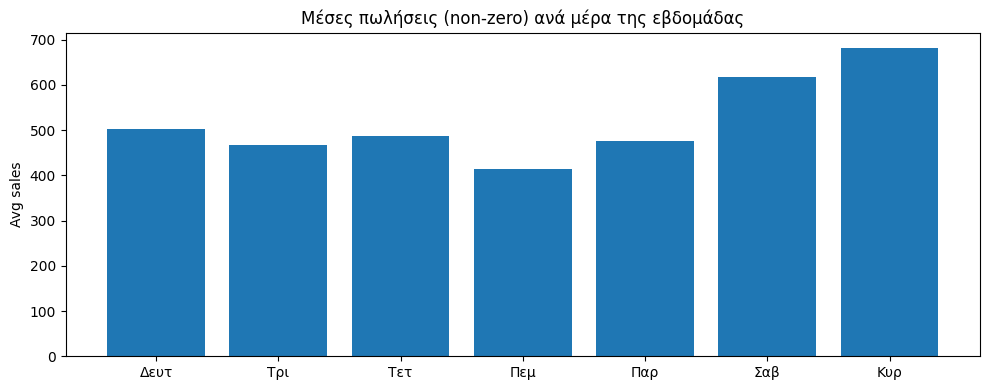

In [19]:
# Μέσες πωλήσεις (non-zero) ανά μέρα της εβδομάδας
day_names = ['Δευτ', 'Τρι', 'Τετ', 'Πεμ', 'Παρ', 'Σαβ', 'Κυρ']
sales_by_dow = df[df['sales'] > 0].groupby('day_of_week')['sales'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(day_names, sales_by_dow.values)
ax.set_title('Μέσες πωλήσεις (non-zero) ανά μέρα της εβδομάδας')
ax.set_ylabel('Avg sales')
plt.tight_layout()
plt.show()

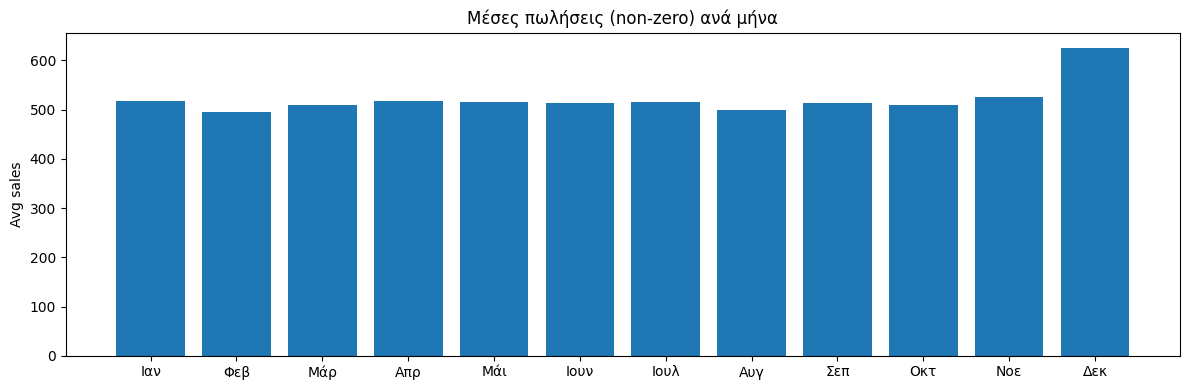

In [20]:
sales_by_month = df[df['sales'] > 0].groupby('month')['sales'].mean()

month_names = ['Ιαν', 'Φεβ', 'Μάρ', 'Απρ', 'Μάι', 'Ιουν', 
               'Ιουλ', 'Αυγ', 'Σεπ', 'Οκτ', 'Νοε', 'Δεκ']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_names, sales_by_month.values)
ax.set_title('Μέσες πωλήσεις (non-zero) ανά μήνα')
ax.set_ylabel('Avg sales')
plt.tight_layout()
plt.show()

Στρατηγική:
1. Φιλτράρουμε structural zeros (store-family pairs με avg sales < 1)
2. Δημιουργούμε 3 κλάσεις (Low/Medium/High) με βάση tertiles
3. Αυτές οι κλάσεις θα είναι το target για το classification task

In [21]:
# Υπολογισμός average sales ανά (store, family) pair
pair_avg = df.groupby(['store_nbr', 'family'])['sales'].mean()

# Identify structural zero pairs (avg < 1)
structural_zero_pairs = pair_avg[pair_avg < 1].index
print(f"Structural zero pairs: {len(structural_zero_pairs)} από {len(pair_avg)} ({100*len(structural_zero_pairs)/len(pair_avg):.1f}%)")

# Φτιάχνουμε ένα set για γρήγορο lookup
zero_pairs_set = set(structural_zero_pairs)

# Φιλτράρισμα: κρατάμε γραμμές που ΔΕΝ είναι σε structural zero pair
print(f"\nΑρχικό shape: {df.shape}")
df_filtered = df[~df.set_index(['store_nbr', 'family']).index.isin(zero_pairs_set)].copy()
print(f"Μετά το φιλτράρισμα: {df_filtered.shape}")
print(f"Αφαιρέθηκαν: {len(df) - len(df_filtered):,} γραμμές ({100*(len(df) - len(df_filtered))/len(df):.1f}%)")

Structural zero pairs: 299 από 1782 (16.8%)

Αρχικό shape: (3000888, 26)
Μετά το φιλτράρισμα: (2497372, 26)
Αφαιρέθηκαν: 503,516 γραμμές (16.8%)


In [22]:
zero_count = (df_filtered['sales'] == 0).sum()
total = len(df_filtered)
print(f"Γραμμές με sales=0 μετά το φιλτράρισμα: {zero_count:,} από {total:,} ({100*zero_count/total:.1f}%)")
print(f"\nΣτατιστικά του φιλτραρισμένου dataset:")
print(df_filtered['sales'].describe().round(2))

Γραμμές με sales=0 μετά το φιλτράρισμα: 512,515 από 2,497,372 (20.5%)

Στατιστικά του φιλτραρισμένου dataset:
count    2497372.00
mean         429.85
std         1195.11
min            0.00
25%            2.00
50%           29.00
75%          276.69
max       124717.00
Name: sales, dtype: float64


In [23]:
# Υπολογισμός tertiles πάνω σε non-zero sales
non_zero_sales = df_filtered.loc[df_filtered['sales'] > 0, 'sales']
q33 = non_zero_sales.quantile(0.33)
q67 = non_zero_sales.quantile(0.67)

print(f"Tertile thresholds (από non-zero sales):")
print(f"  Q33 (Low → Medium): {q33:.2f}")
print(f"  Q67 (Medium → High): {q67:.2f}")

# Συνάρτηση για το mapping
def assign_class(sales):
    if sales <= q33:
        return 'Low'
    elif sales <= q67:
        return 'Medium'
    else:
        return 'High'

df_filtered['sales_class'] = df_filtered['sales'].apply(assign_class)

# Verification
print(f"\nDistribution των κλάσεων:")
print(df_filtered['sales_class'].value_counts())
print(f"\nΠοσοστά:")
print((df_filtered['sales_class'].value_counts(normalize=True) * 100).round(1))

Tertile thresholds (από non-zero sales):
  Q33 (Low → Medium): 20.00
  Q67 (Medium → High): 254.00

Distribution των κλάσεων:
sales_class
Low       1168190
Medium     674795
High       654387
Name: count, dtype: int64

Ποσοστά:
sales_class
Low       46.8
Medium    27.0
High      26.2
Name: proportion, dtype: float64


In [24]:
# Στατιστικά sales ανά class
print("Στατιστικά πωλήσεων ανά κλάση:")
print(df_filtered.groupby('sales_class')['sales'].agg(['min', 'max', 'mean', 'median', 'count']).round(2))

# Δείγμα από κάθε class
print("\nΔείγμα Low:")
print(df_filtered[df_filtered['sales_class'] == 'Low'][['date', 'store_nbr', 'family', 'sales']].sample(3, random_state=42))
print("\nΔείγμα Medium:")
print(df_filtered[df_filtered['sales_class'] == 'Medium'][['date', 'store_nbr', 'family', 'sales']].sample(3, random_state=42))
print("\nΔείγμα High:")
print(df_filtered[df_filtered['sales_class'] == 'High'][['date', 'store_nbr', 'family', 'sales']].sample(3, random_state=42))

Στατιστικά πωλήσεων ανά κλάση:
               min       max     mean  median    count
sales_class                                           
High         254.0  124717.0  1523.70  772.41   654387
Low            0.0      20.0     4.14    2.00  1168190
Medium        20.0     254.0   106.06   92.00   674795

Δείγμα Low:
              date  store_nbr                      family  sales
1632227 2015-07-07          7                    HARDWARE    1.0
1797068 2015-10-08         31             LAWN AND GARDEN    2.0
1513246 2015-05-02         18  SCHOOL AND OFFICE SUPPLIES    0.0

Δείγμα Medium:
              date  store_nbr          family  sales
2005387 2016-02-03         27            EGGS  207.0
2459651 2016-10-15         22  PREPARED FOODS   93.0
989977  2014-07-11         36            EGGS   56.0

Δείγμα High:
              date  store_nbr          family    sales
1156066 2014-10-12         46            EGGS  322.000
1120539 2014-09-22         49           MEATS  576.609
808628  2014-0

In [25]:
# Tertiles από ΟΛΑ τα sales (όχι μόνο non-zero)
q33 = df_filtered['sales'].quantile(0.33)
q67 = df_filtered['sales'].quantile(0.67)

print(f"Νέα tertile thresholds (από όλα τα sales):")
print(f"  Q33 (Low → Medium): {q33:.2f}")
print(f"  Q67 (Medium → High): {q67:.2f}")

# Νέο assignment
def assign_class(sales):
    if sales <= q33:
        return 'Low'
    elif sales <= q67:
        return 'Medium'
    else:
        return 'High'

df_filtered['sales_class'] = df_filtered['sales'].apply(assign_class)

# Verification
print(f"\nDistribution των κλάσεων:")
print(df_filtered['sales_class'].value_counts())
print(f"\nΠοσοστά:")
print((df_filtered['sales_class'].value_counts(normalize=True) * 100).round(1))

Νέα tertile thresholds (από όλα τα sales):
  Q33 (Low → Medium): 6.00
  Q67 (Medium → High): 160.00

Distribution των κλάσεων:
sales_class
Low       860722
High      823019
Medium    813631
Name: count, dtype: int64

Ποσοστά:
sales_class
Low       34.5
High      33.0
Medium    32.6
Name: proportion, dtype: float64


## Encoding κατηγορικών μεταβλητών

Δημιουργούμε νέες αριθμητικές στήλες για κάθε κατηγορική τιμή (one-hot encoding):
- `family` (33 κατηγορίες) → κύριο predictor
- `type` (5 κατηγορίες) → format καταστήματος
- `state` (16 κατηγορίες) → γεωγραφική θέση (προτιμάμε state αντί για city γιατί έχει λιγότερες τιμές)

Επίσης μετατρέπουμε τα boolean flags (is_*) σε integers για συμβατότητα με τα μοντέλα.

In [26]:
# Πριν το encoding - ας δούμε σε τι state είμαστε
print(f"Shape πριν: {df_filtered.shape}")
print(f"Κατηγορικές στήλες: family ({df_filtered['family'].nunique()}), "
      f"type ({df_filtered['type'].nunique()}), "
      f"state ({df_filtered['state'].nunique()})")

# One-hot encoding με pandas get_dummies
df_encoded = pd.get_dummies(
    df_filtered, 
    columns=['family', 'type', 'state'],
    prefix=['family', 'type', 'state'],
    drop_first=False  # κρατάμε όλες τις κατηγορίες
)

print(f"\nShape μετά: {df_encoded.shape}")
print(f"Νέες στήλες προστέθηκαν: {df_encoded.shape[1] - df_filtered.shape[1]}")

Shape πριν: (2497372, 27)
Κατηγορικές στήλες: family (31), type (5), state (16)

Shape μετά: (2497372, 76)
Νέες στήλες προστέθηκαν: 49


In [27]:
# Δείγμα με τις νέες encoded στήλες (μόνο ένα κατάστημα/μία γραμμή για clarity)
sample = df_encoded.head(1).T  # Transpose για να φαίνεται κάθετα
print("Πρώτη γραμμή με όλες τις στήλες (transposed):")
print(sample)

Πρώτη γραμμή με όλες τις στήλες (transposed):
                                                        0
id                                                      0
date                                  2013-01-01 00:00:00
store_nbr                                               1
sales                                                 0.0
onpromotion                                             0
...                                                   ...
state_Pastaza                                       False
state_Pichincha                                      True
state_Santa Elena                                   False
state_Santo Domingo de los Tsachilas                False
state_Tungurahua                                    False

[76 rows x 1 columns]


In [28]:
# Τα is_* flags είναι Booleans. Μετατροπή σε int για ομοιόμορφο dataset.
boolean_cols = ['is_weekend', 'is_month_start', 'is_month_end',
                'is_national_holiday', 'is_regional_holiday', 
                'is_local_holiday', 'is_holiday']

for col in boolean_cols:
    df_encoded[col] = df_encoded[col].astype(int)

# Επίσης τα one-hot έγιναν boolean - τα κάνουμε int
one_hot_cols = [c for c in df_encoded.columns if c.startswith(('family_', 'type_', 'state_'))]
for col in one_hot_cols:
    df_encoded[col] = df_encoded[col].astype(int)

print("Boolean cols converted to int ✓")
print(f"\nDtypes summary:")
print(df_encoded.dtypes.value_counts())

Boolean cols converted to int ✓

Dtypes summary:
int64             64
int32              6
float64            3
str                2
datetime64[us]     1
Name: count, dtype: int64


In [29]:
print(f"Τελικό shape: {df_encoded.shape}")
print(f"\nΌλες οι στήλες:")
print(list(df_encoded.columns))
print(f"\nMemory usage: {df_encoded.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Τελικό shape: (2497372, 76)

Όλες οι στήλες:
['id', 'date', 'store_nbr', 'sales', 'onpromotion', 'city', 'cluster', 'oil_price', 'transactions', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'is_holiday', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'sales_class', 'family_AUTOMOTIVE', 'family_BEAUTY', 'family_BEVERAGES', 'family_BREAD/BAKERY', 'family_CELEBRATION', 'family_CLEANING', 'family_DAIRY', 'family_DELI', 'family_EGGS', 'family_FROZEN FOODS', 'family_GROCERY I', 'family_GROCERY II', 'family_HARDWARE', 'family_HOME AND KITCHEN I', 'family_HOME AND KITCHEN II', 'family_HOME APPLIANCES', 'family_HOME CARE', 'family_LADIESWEAR', 'family_LAWN AND GARDEN', 'family_LINGERIE', 'family_LIQUOR,WINE,BEER', 'family_MAGAZINES', 'family_MEATS', 'family_PERSONAL CARE', 'family_PET SUPPLIES', 'family_PLAYERS AND ELECTRONICS', 'family_POULTRY', 'family_PREPARED FOODS', 'family_PRODUCE', 'fam

In [30]:
# Ποιες families χάθηκαν στο φιλτράρισμα;
all_families = set(df['family'].unique())
remaining_families = set(df_filtered['family'].unique())
removed_families = all_families - remaining_families
print(f"Families που αφαιρέθηκαν εντελώς: {removed_families}")

Families που αφαιρέθηκαν εντελώς: {'BOOKS', 'BABY CARE'}


In [31]:
# 1) Drop redundant string column 'city' (info υπάρχει στο state)
df_encoded = df_encoded.drop(columns=['city'])
print(f"Shape μετά το drop του city: {df_encoded.shape}")

# 2) Memory optimization - downcast types
# Όλα τα int64 που είναι 0/1 → int8
int_cols = df_encoded.select_dtypes(include=['int64', 'int32']).columns
for col in int_cols:
    max_val = df_encoded[col].max()
    min_val = df_encoded[col].min()
    if min_val >= 0 and max_val <= 1:
        df_encoded[col] = df_encoded[col].astype('int8')
    elif min_val >= 0 and max_val <= 255:
        df_encoded[col] = df_encoded[col].astype('int8')
    elif min_val >= -32768 and max_val <= 32767:
        df_encoded[col] = df_encoded[col].astype('int16')

# Float64 → float32 (αρκεί για sales/prices)
float_cols = df_encoded.select_dtypes(include=['float64']).columns
for col in float_cols:
    df_encoded[col] = df_encoded[col].astype('float32')

new_memory = df_encoded.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory μετά: {new_memory:.1f} MB (από 1631.7 MB)")
print(f"\nDtypes summary:")
print(df_encoded.dtypes.value_counts())

Shape μετά το drop του city: (2497372, 75)

Memory μετά: 286.5 MB (από 1631.7 MB)

Dtypes summary:
int8              66
float32            3
int16              3
int64              1
datetime64[us]     1
str                1
Name: count, dtype: int64


## Train/Validation/Test Split

Χρονικός διαχωρισμός (όχι random) για να αποφύγουμε data leakage σε time-series:
- Train: 2013-01-01 → 2016-12-31 (~4 χρόνια)
- Validation: 2017-01-01 → 2017-05-31 (5 μήνες)
- Test: 2017-06-01 → 2017-08-15 (~2.5 μήνες)

Τα μοντέλα θα εκπαιδευτούν στο train, θα γίνει tuning στο validation,
και η τελική αξιολόγηση στο test.

In [32]:
# Χρονικός διαχωρισμός
train_set = df_encoded[df_encoded['date'] < '2017-01-01'].copy()
val_set = df_encoded[(df_encoded['date'] >= '2017-01-01') & (df_encoded['date'] < '2017-06-01')].copy()
test_set = df_encoded[df_encoded['date'] >= '2017-06-01'].copy()

print(f"Train: {train_set.shape} ({train_set['date'].min().date()} → {train_set['date'].max().date()})")
print(f"Val:   {val_set.shape} ({val_set['date'].min().date()} → {val_set['date'].max().date()})")
print(f"Test:  {test_set.shape} ({test_set['date'].min().date()} → {test_set['date'].max().date()})")

# Distribution των classes σε κάθε set
print(f"\nClass distribution:")
print(f"Train: {train_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Val:   {val_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Test:  {test_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")

Train: (2160731, 75) (2013-01-01 → 2016-12-31)
Val:   (223933, 75) (2017-01-01 → 2017-05-31)
Test:  (112708, 75) (2017-06-01 → 2017-08-15)

Class distribution:
Train: {'Low': 0.369, 'High': 0.32, 'Medium': 0.311}
Val:   {'Medium': 0.421, 'High': 0.385, 'Low': 0.194}
Test:  {'Medium': 0.426, 'High': 0.394, 'Low': 0.18}


## Επανυπολογισμός target από train data

Τα tertile thresholds υπολογίζονται **μόνο από το train set** για να αποφύγουμε
data leakage. Αυτό αντικατοπτρίζει την πραγματική χρήση: ορίζουμε classes με
βάση το ιστορικό και τις εφαρμόζουμε στο μέλλον.

Η διανομή κλάσεων στο val/test θα είναι μη-ισόρροπη — αυτό είναι αναμενόμενο
και αντικατοπτρίζει την αύξηση πωλήσεων με τον χρόνο (concept drift).

In [33]:
# Tertiles ΜΟΝΟ από το train
q33_train = train_set['sales'].quantile(0.33)
q67_train = train_set['sales'].quantile(0.67)

print(f"Tertile thresholds (από train set μόνο):")
print(f"  Q33 (Low → Medium): {q33_train:.2f}")
print(f"  Q67 (Medium → High): {q67_train:.2f}")

# Εφαρμογή σε όλα τα sets με τα ίδια thresholds
def assign_class_v2(sales, q33=q33_train, q67=q67_train):
    if sales <= q33:
        return 'Low'
    elif sales <= q67:
        return 'Medium'
    else:
        return 'High'

train_set['sales_class'] = train_set['sales'].apply(assign_class_v2)
val_set['sales_class'] = val_set['sales'].apply(assign_class_v2)
test_set['sales_class'] = test_set['sales'].apply(assign_class_v2)

print(f"\nClass distribution (νέο):")
print(f"Train: {train_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Val:   {val_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Test:  {test_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")

Tertile thresholds (από train set μόνο):
  Q33 (Low → Medium): 4.00
  Q67 (Medium → High): 150.00

Class distribution (νέο):
Train: {'Medium': 0.337, 'Low': 0.334, 'High': 0.33}
Val:   {'Medium': 0.457, 'High': 0.395, 'Low': 0.148}
Test:  {'Medium': 0.463, 'High': 0.404, 'Low': 0.134}


## Αποθήκευση Processed Dataset

Σώζουμε τα 3 sets σε parquet format στον φάκελο `data/processed/`.
Τα επόμενα notebooks (03_eda, 04_models) θα τα φορτώνουν από εκεί 
χωρίς να ξανατρέξουν την επεξεργασία.

In [34]:
q33_train = train_set['sales'].quantile(0.33)
q67_train = train_set['sales'].quantile(0.67)

print(f"Tertile thresholds (από train set μόνο):")
print(f"  Q33 (Low → Medium): {q33_train:.2f}")
print(f"  Q67 (Medium → High): {q67_train:.2f}")

def assign_class_v2(sales, q33=q33_train, q67=q67_train):
    if sales <= q33:
        return 'Low'
    elif sales <= q67:
        return 'Medium'
    else:
        return 'High'

train_set['sales_class'] = train_set['sales'].apply(assign_class_v2)
val_set['sales_class'] = val_set['sales'].apply(assign_class_v2)
test_set['sales_class'] = test_set['sales'].apply(assign_class_v2)

print(f"\nClass distribution (νέο):")
print(f"Train: {train_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Val:   {val_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Test:  {test_set['sales_class'].value_counts(normalize=True).round(3).to_dict()}")

Tertile thresholds (από train set μόνο):
  Q33 (Low → Medium): 4.00
  Q67 (Medium → High): 150.00

Class distribution (νέο):
Train: {'Medium': 0.337, 'Low': 0.334, 'High': 0.33}
Val:   {'Medium': 0.457, 'High': 0.395, 'Low': 0.148}
Test:  {'Medium': 0.463, 'High': 0.404, 'Low': 0.134}


In [35]:
import os

os.makedirs('../data/processed', exist_ok=True)

train_set.to_parquet('../data/processed/train.parquet', index=False)
val_set.to_parquet('../data/processed/val.parquet', index=False)
test_set.to_parquet('../data/processed/test.parquet', index=False)

for name, path in [('train', '../data/processed/train.parquet'),
                    ('val', '../data/processed/val.parquet'),
                    ('test', '../data/processed/test.parquet')]:
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  {name}.parquet: {size_mb:.1f} MB")

print("\nΑποθήκευση ολοκληρώθηκε ✓")

  train.parquet: 17.3 MB
  val.parquet: 2.2 MB
  test.parquet: 1.2 MB

Αποθήκευση ολοκληρώθηκε ✓


In [36]:
train_reloaded = pd.read_parquet('../data/processed/train.parquet')
print(f"Reloaded train shape: {train_reloaded.shape}")
print(f"\nDtypes (πρώτες 10):")
print(train_reloaded.dtypes.head(10))
print(f"\nClass distribution:")
print(train_reloaded['sales_class'].value_counts(normalize=True).round(3))

Reloaded train shape: (2160731, 75)

Dtypes (πρώτες 10):
id                              int64
date                   datetime64[us]
store_nbr                        int8
sales                         float32
onpromotion                     int16
cluster                          int8
oil_price                     float32
transactions                  float32
is_national_holiday              int8
is_regional_holiday              int8
dtype: object

Class distribution:
sales_class
Medium    0.337
Low       0.334
High      0.330
Name: proportion, dtype: float64
